# Embedding from scratch

In this experiment, we build an embedding algorithm (like word2vec) from scratch, following and adapting the following tutorial : https://jaketae.github.io/study/word2vec/

## I. Preparing data

In [37]:
text = '''Machine learning is the study of computer algorithms that \
improve automatically through experience. It is seen as a \
subset of artificial intelligence. Machine learning algorithms \
build a mathematical model based on sample data, known as \
training data, in order to make predictions or decisions without \
being explicitly programmed to do so. Machine learning algorithms \
are used in a wide variety of applications, such as email filtering \
and computer vision, where it is difficult or infeasible to develop \
conventional algorithms to perform the needed tasks.'''

In [38]:
import re

def tokenize(text):
    pattern = re.compile(r'[A-Za-z]+[\w^\']*|[\w^\']*[A-Za-z]+[\w^\']*')
    return pattern.findall(text.lower())

tokens = tokenize(text)
tokens

['machine',
 'learning',
 'is',
 'the',
 'study',
 'of',
 'computer',
 'algorithms',
 'that',
 'improve',
 'automatically',
 'through',
 'experience',
 'it',
 'is',
 'seen',
 'as',
 'a',
 'subset',
 'of',
 'artificial',
 'intelligence',
 'machine',
 'learning',
 'algorithms',
 'build',
 'a',
 'mathematical',
 'model',
 'based',
 'on',
 'sample',
 'data',
 'known',
 'as',
 'training',
 'data',
 'in',
 'order',
 'to',
 'make',
 'predictions',
 'or',
 'decisions',
 'without',
 'being',
 'explicitly',
 'programmed',
 'to',
 'do',
 'so',
 'machine',
 'learning',
 'algorithms',
 'are',
 'used',
 'in',
 'a',
 'wide',
 'variety',
 'of',
 'applications',
 'such',
 'as',
 'email',
 'filtering',
 'and',
 'computer',
 'vision',
 'where',
 'it',
 'is',
 'difficult',
 'or',
 'infeasible',
 'to',
 'develop',
 'conventional',
 'algorithms',
 'to',
 'perform',
 'the',
 'needed',
 'tasks']

In [39]:
def mapping(tokens):
    word_to_id = {}
    id_to_word = {}
    
    for i, token in enumerate(set(tokens)):
        word_to_id[token] = i
        id_to_word[i] = token
    
    return word_to_id, id_to_word
word_to_id, id_to_word = mapping(tokens)
word_to_id, id_to_word 

({'explicitly': 0,
  'needed': 1,
  'learning': 2,
  'being': 3,
  'build': 4,
  'based': 5,
  'artificial': 6,
  'improve': 7,
  'experience': 8,
  'it': 9,
  'study': 10,
  'through': 11,
  'training': 12,
  'such': 13,
  'develop': 14,
  'or': 15,
  'difficult': 16,
  'automatically': 17,
  'tasks': 18,
  'infeasible': 19,
  'the': 20,
  'wide': 21,
  'is': 22,
  'model': 23,
  'conventional': 24,
  'to': 25,
  'machine': 26,
  'used': 27,
  'filtering': 28,
  'intelligence': 29,
  'subset': 30,
  'email': 31,
  'sample': 32,
  'so': 33,
  'vision': 34,
  'without': 35,
  'computer': 36,
  'algorithms': 37,
  'make': 38,
  'mathematical': 39,
  'variety': 40,
  'do': 41,
  'predictions': 42,
  'perform': 43,
  'that': 44,
  'programmed': 45,
  'of': 46,
  'are': 47,
  'a': 48,
  'and': 49,
  'decisions': 50,
  'data': 51,
  'known': 52,
  'as': 53,
  'where': 54,
  'in': 55,
  'applications': 56,
  'order': 57,
  'on': 58,
  'seen': 59},
 {0: 'explicitly',
  1: 'needed',
  2: 'learn

In [40]:
import numpy as np

np.random.seed(42)

def generate_training_data(tokens, word_to_id, window):
    X = []
    y = []
    n_tokens = len(tokens)
    
    for i in range(n_tokens):
        idx = concat(
            range(max(0, i - window), i), 
            range(i, min(n_tokens, i + window + 1))
        )
        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encode(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encode(word_to_id[tokens[j]], len(word_to_id)))
    
    return np.asarray(X), np.asarray(y)

def concat(*iterables):
    for iterable in iterables:
        yield from iterable

def one_hot_encode(id, vocab_size):
    res = [0] * vocab_size
    res[id] = 1
    return res

In [41]:
X, y = generate_training_data(tokens, word_to_id, 2)
X, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(330, 60)),
 array([[0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0]], shape=(330, 60)))

## The Embedding Model
### Code Implementation

In [42]:
def init_network(vocab_size, n_embedding):
    model = {
        "w1": np.random.randn(vocab_size, n_embedding),
        "w2": np.random.randn(n_embedding, vocab_size)
    }
    return model


In [43]:
model = init_network(len(word_to_id), 10)

In [44]:
def forward(model, X, return_cache=True):
    cache = {}
    
    cache["a1"] = X @ model["w1"]
    cache["a2"] = cache["a1"] @ model["w2"]
    cache["z"] = softmax(cache["a2"])
    
    if not return_cache:
        return cache["z"]
    return cache


In [45]:
def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res


In [46]:
(X @ model["w1"]).shape

(330, 10)

In [47]:
def backward(model, X, y, alpha):

    #No need to add return model since it is a dictionary, which is mutable (like lists)
    
    cache  = forward(model, X)
    da2 = cache["z"] - y
    dw2 = cache["a1"].T @ da2
    da1 = da2 @ model["w2"].T
    dw1 = X.T @ da1
    assert(dw2.shape == model["w2"].shape)
    assert(dw1.shape == model["w1"].shape)
    model["w1"] -= alpha * dw1
    model["w2"] -= alpha * dw2
    return cross_entropy(cache["z"], y)

def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)

## Testing the model

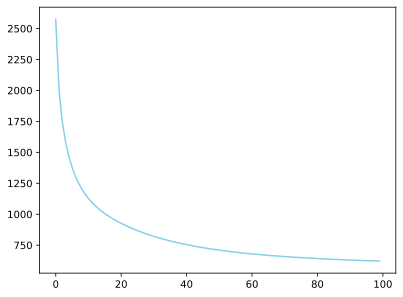

In [48]:
import matplotlib.pyplot as plt


n_iter = 100
learning_rate = 0.02

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]

plt.plot(range(len(history)), history, color="skyblue")
plt.show()


In [49]:
learning = one_hot_encode(word_to_id["learning"], len(word_to_id))
result = forward(model, [learning], return_cache=False)[0]

for word in (id_to_word[id] for id in np.argsort(result)[::-1]):
    print(word)


machine
algorithms
intelligence
the
is
are
build
so
learning
to
study
predictions
mathematical
needed
known
subset
infeasible
based
data
a
difficult
being
where
on
seen
of
artificial
training
model
decisions
that
make
tasks
order
or
perform
without
experience
conventional
vision
used
variety
sample
wide
filtering
programmed
through
such
computer
applications
develop
explicitly
improve
do
and
in
email
automatically
it
as


## Embedding

In [52]:
model["w1"]


array([[ 1.99123264e-01,  8.47091535e-01,  1.45774354e+00,
         1.70582291e+00,  5.01386164e-01, -7.94173506e-01,
         1.57843828e+00,  6.76818585e-01, -6.79854596e-01,
         1.07510524e+00],
       [-1.93709899e+00, -5.11209457e-01,  1.32349688e+00,
        -1.57858829e+00, -2.01354686e+00, -5.86357111e-01,
        -4.24367657e-01,  7.61132853e-01, -1.28449686e+00,
        -1.66938411e+00],
       [ 1.91666762e-01, -1.44454707e+00, -1.03620596e+00,
         1.02003802e-01, -4.80938848e-01, -1.25413906e+00,
         1.19311956e+00,  2.55410884e+00, -1.72078116e-03,
        -5.02145345e-01],
       [ 9.56848192e-02,  2.22946694e+00,  7.98397052e-01,
        -1.14829540e+00,  7.75274348e-01, -1.60405685e+00,
         9.94463435e-01, -1.37301250e+00, -1.73951450e+00,
         7.69327460e-02],
       [-5.02055747e-02, -1.93043602e+00, -8.05188673e-01,
         6.63196333e-01, -6.68710880e-01, -1.01472821e+00,
        -5.02697510e-01,  5.21929319e-02,  8.65017688e-01,
        -6.

In [53]:
def get_embedding(model, word):
    try:
        idx = word_to_id[word]
    except KeyError:
        print("`word` not in corpus")
    one_hot = one_hot_encode(idx, len(word_to_id))
    return forward(model, one_hot)["a1"]


In [54]:
get_embedding(model, "machine")


array([ 0.85628365,  0.00953321, -3.18680922, -0.12740329, -0.88909864,
       -2.12099274,  1.45880511, -0.6866307 ,  1.06340756, -0.28976968])

In [60]:
#euclidean distance between "is" and "are"

sum((get_embedding(model, "intelligence") - get_embedding(model, "learning")) ** 2) ** 0.5


np.float64(3.827659648013718)

In [62]:
sum((get_embedding(model, "predictions") - get_embedding(model, "decisions")) ** 2) ** 0.5

np.float64(3.400344275297338)